In [1]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

# Setup

In [3]:
# Recharger les données et le modèle baseline
df = pd.read_csv("../data/01_raw/Churn_Modelling.csv")
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_features = ['Geography', 'Gender']

# Réentraîner le modèle baseline
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    class_weights={0: 1, 1: 4},
    cat_features=cat_features,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)

model.fit(X_train, y_train)
print("Modèle entraîné !")

Modèle entraîné !


# Calculer les valeurs SHAP

In [4]:
# TreeExplainer est optimisé pour les modèles à base d'arbres
# CatBoost, XGBoost, Random Forest → TreeExplainer
# Modèles linéaires → LinearExplainer
# N'importe quel modèle → KernelExplainer (plus lent)

explainer = shap.TreeExplainer(model)

# Calculer les valeurs SHAP sur le test set
# On prend 500 exemples pour que ce soit rapide
X_test_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_test_sample)

print(f"Shape shap_values : {shap_values.shape}")
print(f"Base value        : {explainer.expected_value:.4f}")
print(f"\nPour le premier client :")
for feat, val in zip(X_test.columns, shap_values[0]):
    print(f"  {feat:20s} → SHAP = {val:+.4f}")

Shape shap_values : (500, 10)
Base value        : -1.2763

Pour le premier client :
  CreditScore          → SHAP = +0.0707
  Geography            → SHAP = -0.0911
  Gender               → SHAP = -0.2981
  Age                  → SHAP = -0.1906
  Tenure               → SHAP = +0.0105
  Balance              → SHAP = -0.2982
  NumOfProducts        → SHAP = -0.9989
  HasCrCard            → SHAP = -0.0180
  IsActiveMember       → SHAP = +0.4646
  EstimatedSalary      → SHAP = +0.3372


Log-odds = -1.2763
→ probabilité = 1 / (1 + e^(1.2763))
→ probabilité ≈ 22%

In [5]:
print(X_test.iloc[0][['IsActiveMember', 'NumOfProducts', 
                        'Balance', 'Age', 'Geography']])

IsActiveMember         0
NumOfProducts          2
Balance              0.0
Age                   36
Geography         France
Name: 5702, dtype: object


#### Interprétation complète du client 5702 :

IsActiveMember = 0  → SHAP = +0.4646
→ il est INACTIF → augmente le risque de churn ✅ logique

NumOfProducts = 2   → SHAP = -0.9989
→ il a 2 produits → diminue FORTEMENT le risque ✅ logique

Balance = 0         → SHAP = -0.2982
→ compte vide → diminue le risque
→ logique : pas d'argent = pas intéressant pour concurrents

Age = 36            → SHAP = -0.1906
→ jeune → diminue le risque
→ logique : clients jeunes sont plus fidèles

Geography = France  → SHAP = -0.0911
→ France = moins de churn qu'Allemagne ✅

Conclusion sur ce client :

Base value          = -1.28 (≈22% de churn)

IsActiveMember=0    → +0.46 (mauvais signe)

EstimatedSalary     → +0.34 (mauvais signe)

NumOfProducts=2     → -0.99 (très bon signe)

Balance=0           → -0.30 (bon signe)

→ Les features positives compensent les négatives

→ Ce client va probablement RESTER

# Summary Plot

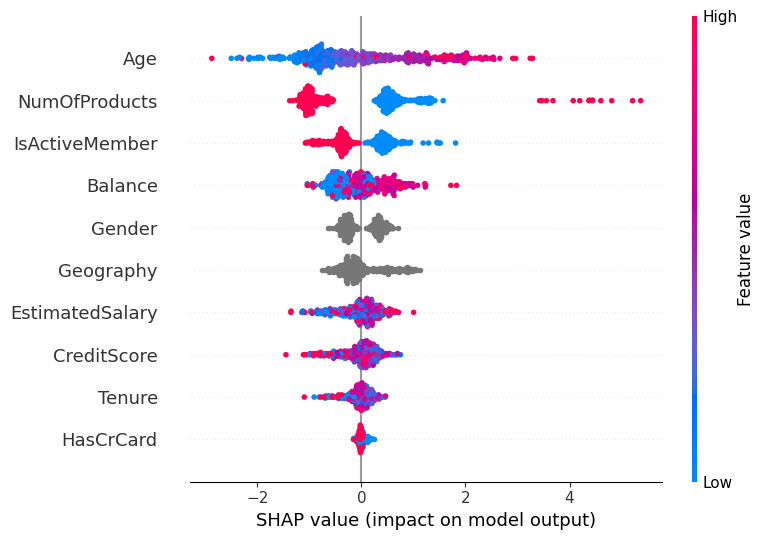

<Figure size 640x480 with 0 Axes>

In [6]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="dot",
    show=True
)
plt.tight_layout()
plt.savefig("../data/08_reporting/shap_summary.png", 
            bbox_inches='tight', dpi=150)
plt.show()

# Demo 

In [9]:
# 3 clients choisis manuellement
clients = pd.DataFrame({
    'CreditScore':      [650,  800,  500],
    'Geography':        ['Germany', 'France', 'Germany'],
    'Gender':           ['Female', 'Male', 'Female'],
    'Age':              [55,   28,   45],
    'Tenure':           [2,    8,    1],
    'Balance':          [125000, 0, 98000],
    'NumOfProducts':    [1,   3,   1],
    'HasCrCard':        [1,   1,   0],
    'IsActiveMember':   [0,   1,   0],
    'EstimatedSalary':  [80000, 50000, 60000]
})

clients.index = ['Ahmed', 'Sophie', 'Maria']

# Prédictions du modèle
probas = model.predict_proba(clients)[:, 1]
predictions = model.predict(clients)

print("Prediction du modele \n")
for nom, proba, pred in zip(clients.index, probas, predictions):
    statut = "CHURN ❌" if pred == 1 else "RESTE ✅"
    print(f"{nom:8s} → {statut} | Probabilité churn : {proba*100:.1f}%")

# Valeurs SHAP
shap_vals = explainer.shap_values(clients)

print("\n Contributions sharp \n")
for i, nom in enumerate(clients.index):
    print(f"\n--- {nom} ---")
    contributions = pd.Series(shap_vals[i], index=clients.columns)
    contributions = contributions.sort_values(key=abs, ascending=False)
    for feat, val in contributions.items():
        sens = "↑ churn" if val > 0 else "↓ churn"
        print(f"  {feat:20s} : {val:+.3f}  {sens}")

Prediction du modele 

Ahmed    → CHURN ❌ | Probabilité churn : 98.3%
Sophie   → RESTE ✅ | Probabilité churn : 23.9%
Maria    → CHURN ❌ | Probabilité churn : 92.7%

 Contributions sharp 


--- Ahmed ---
  Age                  : +2.515  ↑ churn
  IsActiveMember       : +0.848  ↑ churn
  Geography            : +0.755  ↑ churn
  NumOfProducts        : +0.609  ↑ churn
  Balance              : +0.397  ↑ churn
  Gender               : +0.193  ↑ churn
  CreditScore          : +0.146  ↑ churn
  EstimatedSalary      : -0.140  ↓ churn
  Tenure               : +0.003  ↑ churn
  HasCrCard            : -0.002  ↓ churn

--- Sophie ---
  NumOfProducts        : +3.181  ↑ churn
  Age                  : -1.067  ↓ churn
  Balance              : -1.048  ↓ churn
  CreditScore          : -0.429  ↓ churn
  IsActiveMember       : -0.351  ↓ churn
  Gender               : -0.327  ↓ churn
  EstimatedSalary      : +0.237  ↑ churn
  Tenure               : -0.100  ↓ churn
  HasCrCard            : +0.017  ↑ churn
  

In [10]:
print("PROFILS DES 3 CLIENTS \n")
print(clients[['Age', 'IsActiveMember', 'Geography', 
               'Balance', 'NumOfProducts']])

PROFILS DES 3 CLIENTS 

        Age  IsActiveMember Geography  Balance  NumOfProducts
Ahmed    55               0   Germany   125000              1
Sophie   28               1    France        0              3
Maria    45               0   Germany    98000              1


Ahmed  → Age=55 ✅, Inactif ✅, Allemagne ✅

         → CHURN à 98.3% — tout confirme

Sophie → Age=28 ✅, Active ✅, Balance=0 ✅

         → RESTE à 76.1% — tout confirme
         
         → NumOfProducts=3 → SHAP +3.181
         
         → bizarre, 3 produits devrait le faire rester...

Maria  → Age=45 ✅, Inactive ✅, Allemagne ✅

         → CHURN à 92.7% — tout confirme

# Waterfall Plot

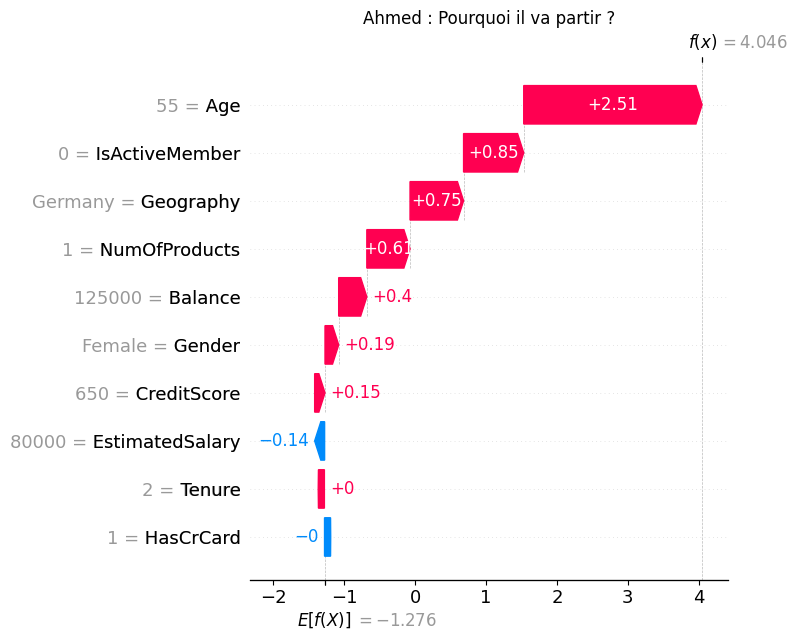

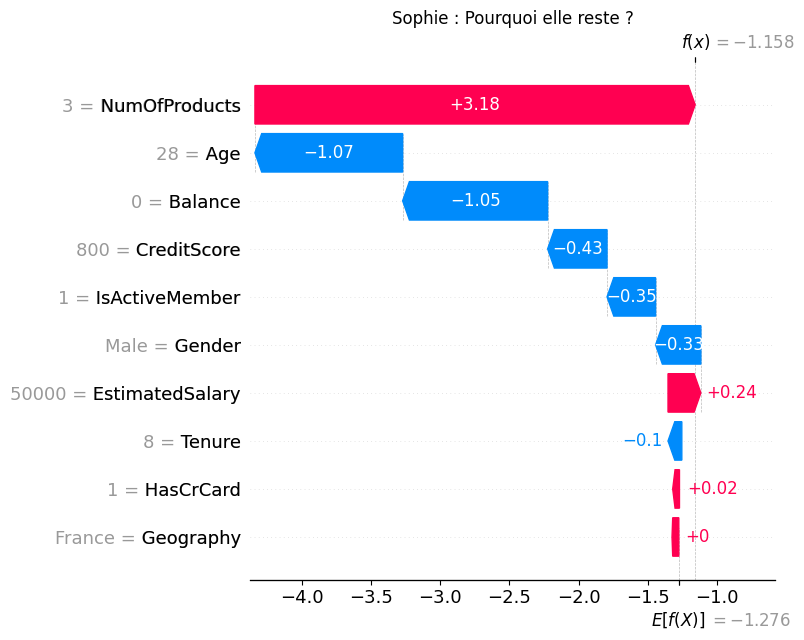

In [14]:
# Waterfall pour Ahmed — churner à 98.3%
position_ahmed = 0

explanation_ahmed = shap.Explanation(
    values=explainer.shap_values(clients)[position_ahmed],
    base_values=explainer.expected_value,
    data=clients.iloc[position_ahmed].values,
    feature_names=clients.columns.tolist()
)

shap.plots.waterfall(explanation_ahmed, show=False)
plt.title("Ahmed : Pourquoi il va partir ?")
plt.tight_layout()
plt.savefig("../data/08_reporting/shap_waterfall_ahmed.png",
            bbox_inches='tight', dpi=150)
plt.show()

# Waterfall pour Sophie — reste à 76.1%
position_sophie = 1

explanation_sophie = shap.Explanation(
    values=explainer.shap_values(clients)[position_sophie],
    base_values=explainer.expected_value,
    data=clients.iloc[position_sophie].values,
    feature_names=clients.columns.tolist()
)

shap.plots.waterfall(explanation_sophie, show=False)
plt.title("Sophie : Pourquoi elle reste ?")
plt.tight_layout()
plt.savefig("../data/08_reporting/shap_waterfall_sophie.png",
            bbox_inches='tight', dpi=150)
plt.show()

### Analyse SHAP : Customer Churn

Notre modèle CatBoost a analysé le profil de trois clients de la banque. Voici ce que les valeurs SHAP nous révèlent sur chacun d'eux.

### Ahmed : Client à risque élevé (98.3% de probabilité de churn)

Ahmed est un client de 55 ans, inactif, domicilié en Allemagne avec un solde de 125 000€. Notre modèle prédit qu'il va très probablement quitter la banque. Les trois facteurs principaux qui expliquent cette décision sont son âge avancé (+2.51), son inactivité sur le compte (+0.85) et sa localisation en Allemagne (+0.75), région où la concurrence bancaire est particulièrement forte. Son solde élevé constitue également un signal d'alarme (+0.40) car il le rend attractif pour les banques concurrentes. Action recommandée : contact urgent par un conseiller avec une offre personnalisée.

### Sophie : Cliente fidèle (23.9% de probabilité de churn)

Sophie est une cliente de 28 ans, active, basée en France avec un compte à solde nul. Notre modèle prédit qu'elle va rester. Son jeune âge (-1.07), son solde nul (-1.05) et son engagement actif (-0.35) sont les principaux facteurs qui la maintiennent dans la banque. Cependant, son nombre de produits élevé (3 produits, +3.18) constitue un signal d'alarme à surveiller , statistiquement les clients avec 3 produits ou plus tendent à partir plus souvent, peut-être en raison de frais bancaires jugés trop élevés. Action recommandée : appel préventif pour vérifier sa satisfaction.


# Bar Plot

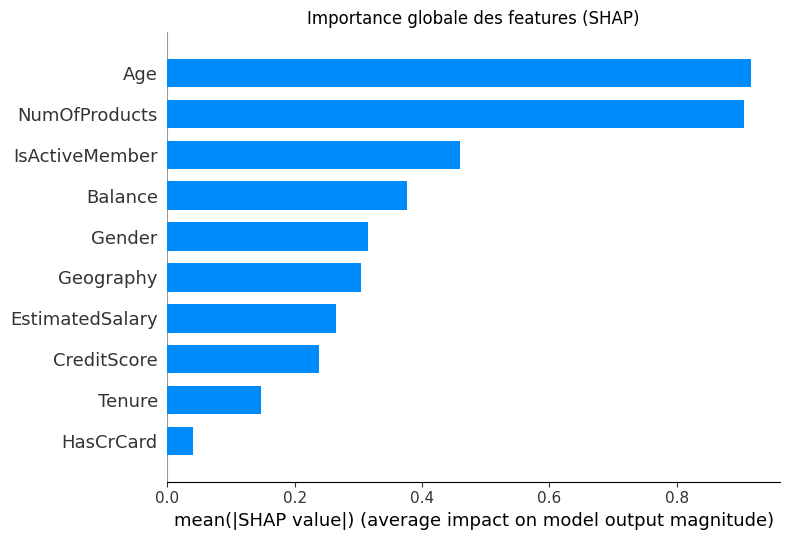

In [13]:
# Bar plot : importance moyenne absolue
shap_values_test = explainer.shap_values(X_test_sample)

shap.summary_plot(
    shap_values_test,
    X_test_sample,
    plot_type="bar",
    show=False
)
plt.title("Importance globale des features (SHAP)")
plt.tight_layout()
plt.savefig("../data/08_reporting/shap_barplot.png",
            bbox_inches='tight', dpi=150)
plt.show()